# World Cup 2026 Predictor - Tournament Simulation

This notebook runs the full Monte Carlo simulation and explores the results.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import PROCESSED_DIR, RAW_DIR, N_SIMULATIONS
from src.simulation.simulator import WorldCupSimulator
from src.visualization.plots import plot_tournament_probabilities, plot_round_probabilities, plot_group_heatmaps, plot_match_predictions
from src.visualization.tables import format_power_rankings, format_group_tables, format_bracket_summary, format_match_predictions

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Run Simulation

In [2]:
n_sim = 1000
print(f'Running {n_sim} simulations...')
simulator = WorldCupSimulator(n_simulations=n_sim)
results = simulator.run_full_simulation()

2026-06-15 09:12:58,225 [INFO] worldcup: Loaded 48 group entries from /Users/sithea/Documents/code/worldcup/data/raw/wc2026_groups.csv
2026-06-15 09:12:58,226 [INFO] worldcup: Loaded 72 fixtures from /Users/sithea/Documents/code/worldcup/data/raw/wc2026_fixtures.csv


Running 1000 simulations...


2026-06-15 09:12:58,298 [INFO] worldcup: Loaded 72 WC 2026 features from /Users/sithea/Documents/code/worldcup/data/processed/wc2026_match_features.parquet
2026-06-15 09:12:58,300 [INFO] worldcup: Loaded 10 live results
2026-06-15 09:12:58,320 [INFO] worldcup: Loaded simulation model from /Users/sithea/Documents/code/worldcup/data/processed/models/xgboost.joblib
2026-06-15 09:12:58,320 [INFO] worldcup: Running full tournament simulation (1000 iterations)...
Tournament simulations: 100%|██████████| 1000/1000 [01:41<00:00,  9.86it/s]
2026-06-15 09:14:39,786 [INFO] worldcup: Tournament probabilities saved to /Users/sithea/Documents/code/worldcup/data/processed/tournament_probabilities.csv
2026-06-15 09:14:39,788 [INFO] worldcup: Group stage probabilities saved to /Users/sithea/Documents/code/worldcup/data/processed/group_stage_probabilities.csv


## 2. Match Predictions

In [3]:
match_preds = simulator.predict_all_matches()
formatted = format_match_predictions(match_preds)
print(formatted)

2026-06-15 09:14:39,806 [INFO] worldcup: Predicting all WC 2026 matches...
2026-06-15 09:14:39,871 [INFO] worldcup: Match predictions saved to /Users/sithea/Documents/code/worldcup/data/processed/match_predictions.csv (72 matches)
2026-06-15 09:14:39,871 [INFO] worldcup: Formatting match predictions...
2026-06-15 09:14:39,876 [INFO] worldcup: 
                             WORLD CUP 2026 MATCH PREDICTIONS                             

Group A:
------------------------------------------------------------------------------------------
Home                  Away                  H Win%    Draw%     A Win%    Prediction
------------------------------------------------------------------------------------------
Mexico                South Korea           54.8      32.6      12.5      home_win  
Mexico                Czech Republic        36.9      57.0      6.1       draw      
Mexico                South Africa          72.1      25.0      2.9       home_win  
South Korea           Czech Rep

                             WORLD CUP 2026 MATCH PREDICTIONS                             

Group A:
------------------------------------------------------------------------------------------
Home                  Away                  H Win%    Draw%     A Win%    Prediction
------------------------------------------------------------------------------------------
Mexico                South Korea           54.8      32.6      12.5      home_win  
Mexico                Czech Republic        36.9      57.0      6.1       draw      
Mexico                South Africa          72.1      25.0      2.9       home_win  
South Korea           Czech Republic        18.2      50.4      31.4      draw      
South Korea           South Africa          48.2      38.0      13.8      home_win  
Czech Republic        South Africa          41.0      25.0      34.0      home_win  

Group B:
------------------------------------------------------------------------------------------
Home                 

2026-06-15 09:14:39,880 [INFO] worldcup: Plotting match predictions...


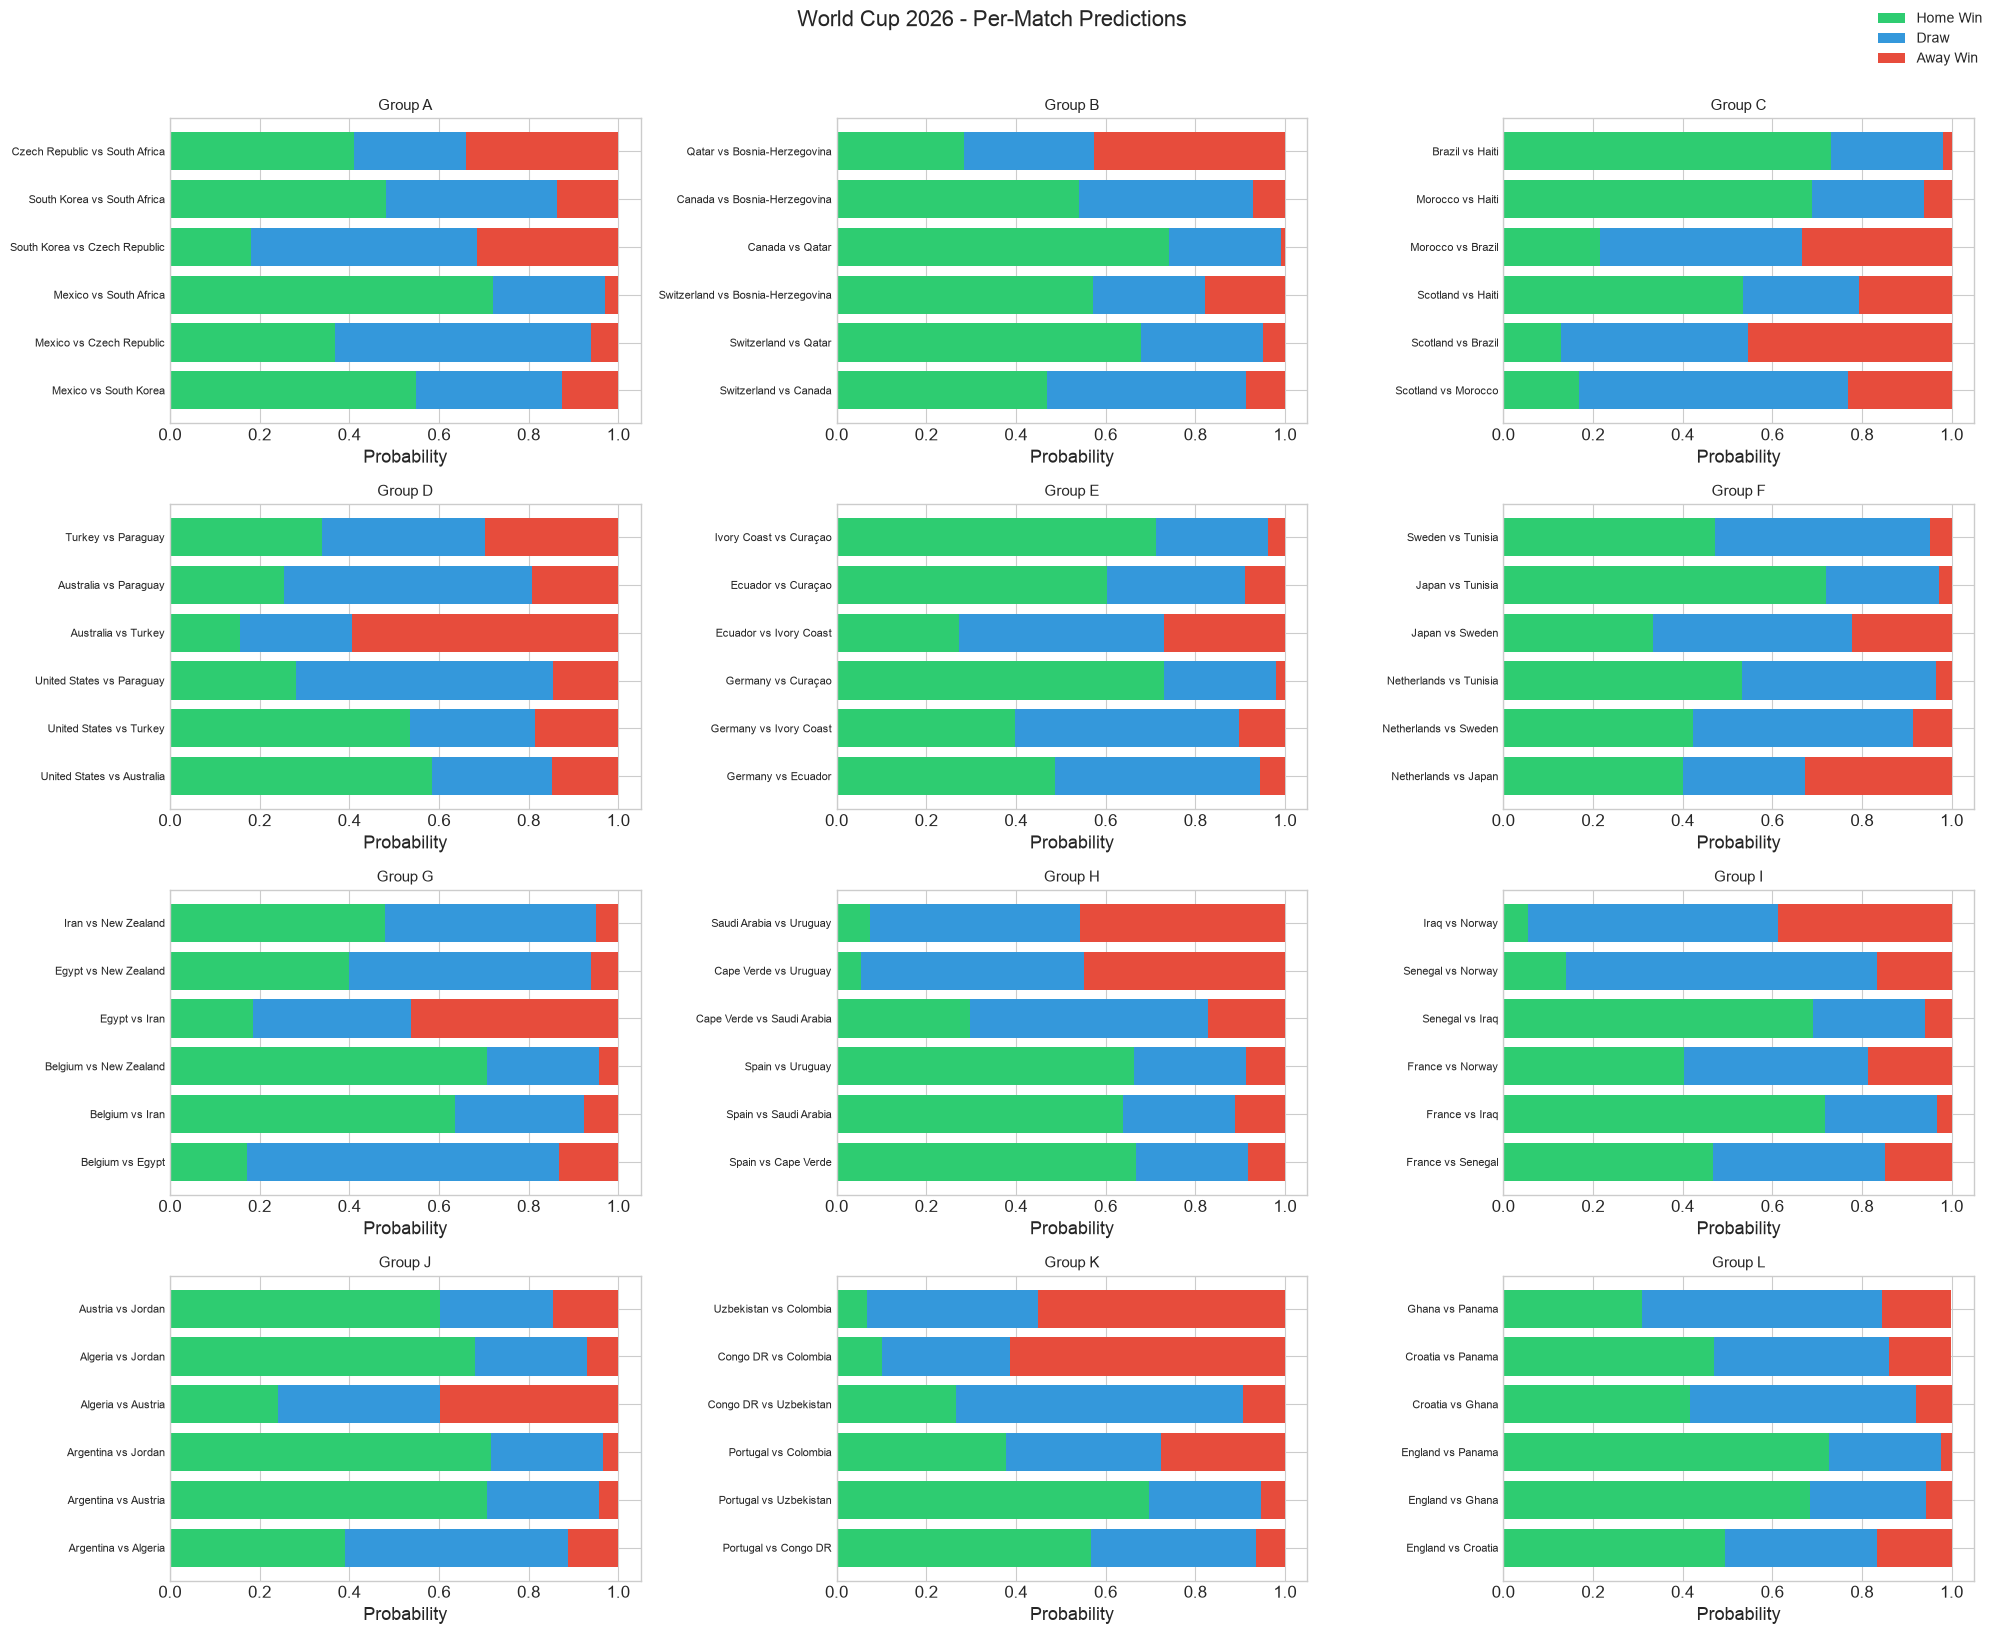

In [4]:
plot_match_predictions(match_preds, save=False)
plt.show()

## 3. Power Rankings

In [5]:
power_rankings = format_power_rankings(results)
print(power_rankings)

2026-06-15 09:14:40,414 [INFO] worldcup: Formatting power rankings...
2026-06-15 09:14:40,416 [INFO] worldcup: 
                                   WORLD CUP 2026 POWER RANKINGS                                    
Rank  Team                     Win%      Final%    SF%       QF%       Ro16%     
----------------------------------------------------------------------------------------------------
1     Mexico                   7.60      7.60      15.10     33.80     61.90     
2     Switzerland              6.50      6.50      12.10     24.70     45.60     
3     United States            6.00      6.00      12.30     22.50     49.40     
4     Germany                  4.80      4.80      9.20      39.40     66.90     
5     Canada                   4.70      4.70      8.90      16.50     29.70     
6     Spain                    4.30      4.30      6.00      21.50     50.40     
7     France                   3.90      3.90      9.40      15.00     28.70     
8     Scotland                

                                   WORLD CUP 2026 POWER RANKINGS                                    
Rank  Team                     Win%      Final%    SF%       QF%       Ro16%     
----------------------------------------------------------------------------------------------------
1     Mexico                   7.60      7.60      15.10     33.80     61.90     
2     Switzerland              6.50      6.50      12.10     24.70     45.60     
3     United States            6.00      6.00      12.30     22.50     49.40     
4     Germany                  4.80      4.80      9.20      39.40     66.90     
5     Canada                   4.70      4.70      8.90      16.50     29.70     
6     Spain                    4.30      4.30      6.00      21.50     50.40     
7     France                   3.90      3.90      9.40      15.00     28.70     
8     Scotland                 3.90      3.90      7.50      14.20     29.50     
9     Brazil                   3.90      3.90      7.90     

## 4. Winning Probabilities Chart

2026-06-15 09:14:40,425 [INFO] worldcup: Plotting tournament probabilities...


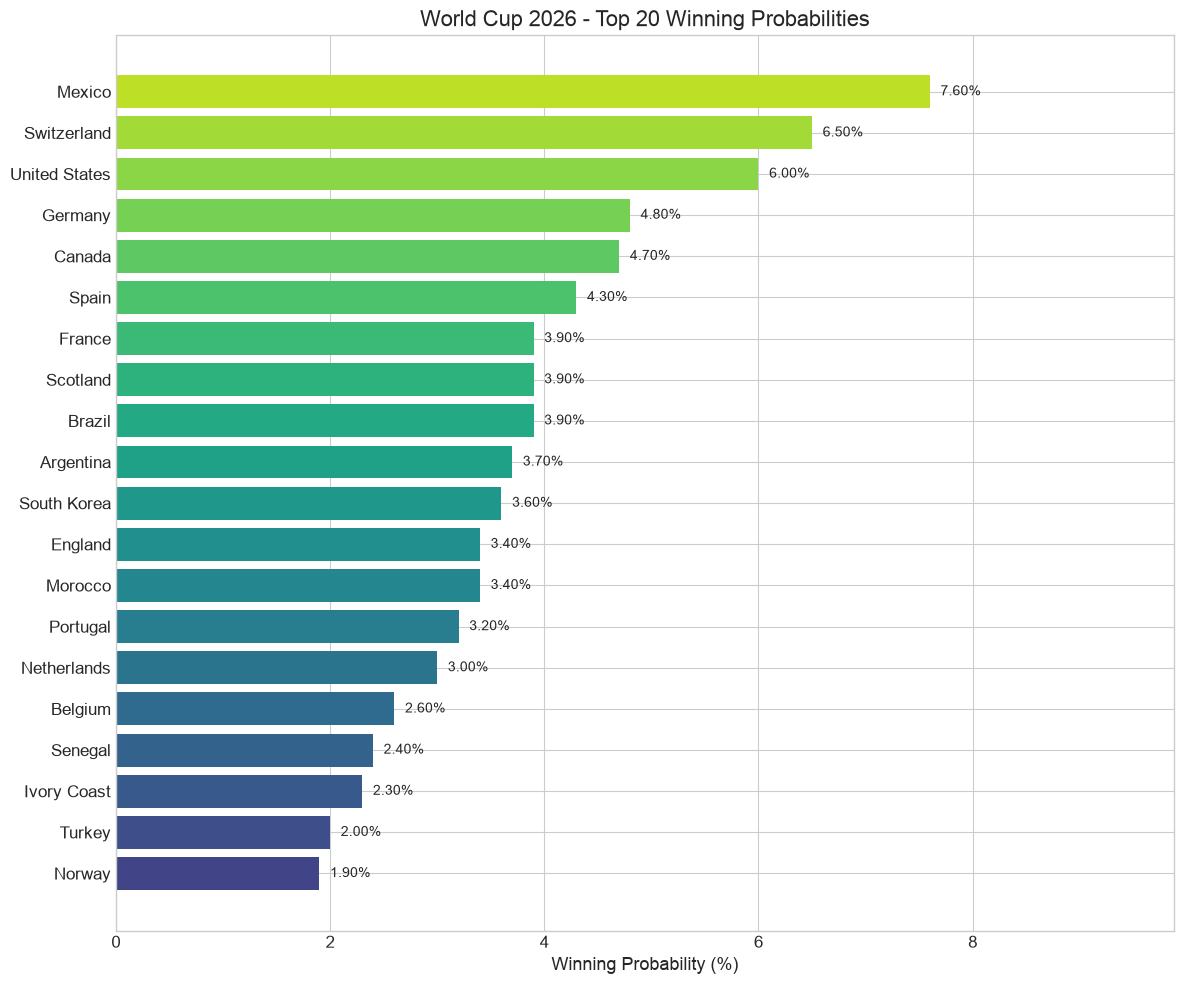

In [6]:
plot_tournament_probabilities(results, top_n=20, save=False)
plt.show()

## 5. Round Advancement Probabilities

2026-06-15 09:14:40,532 [INFO] worldcup: Plotting round advancement probabilities...


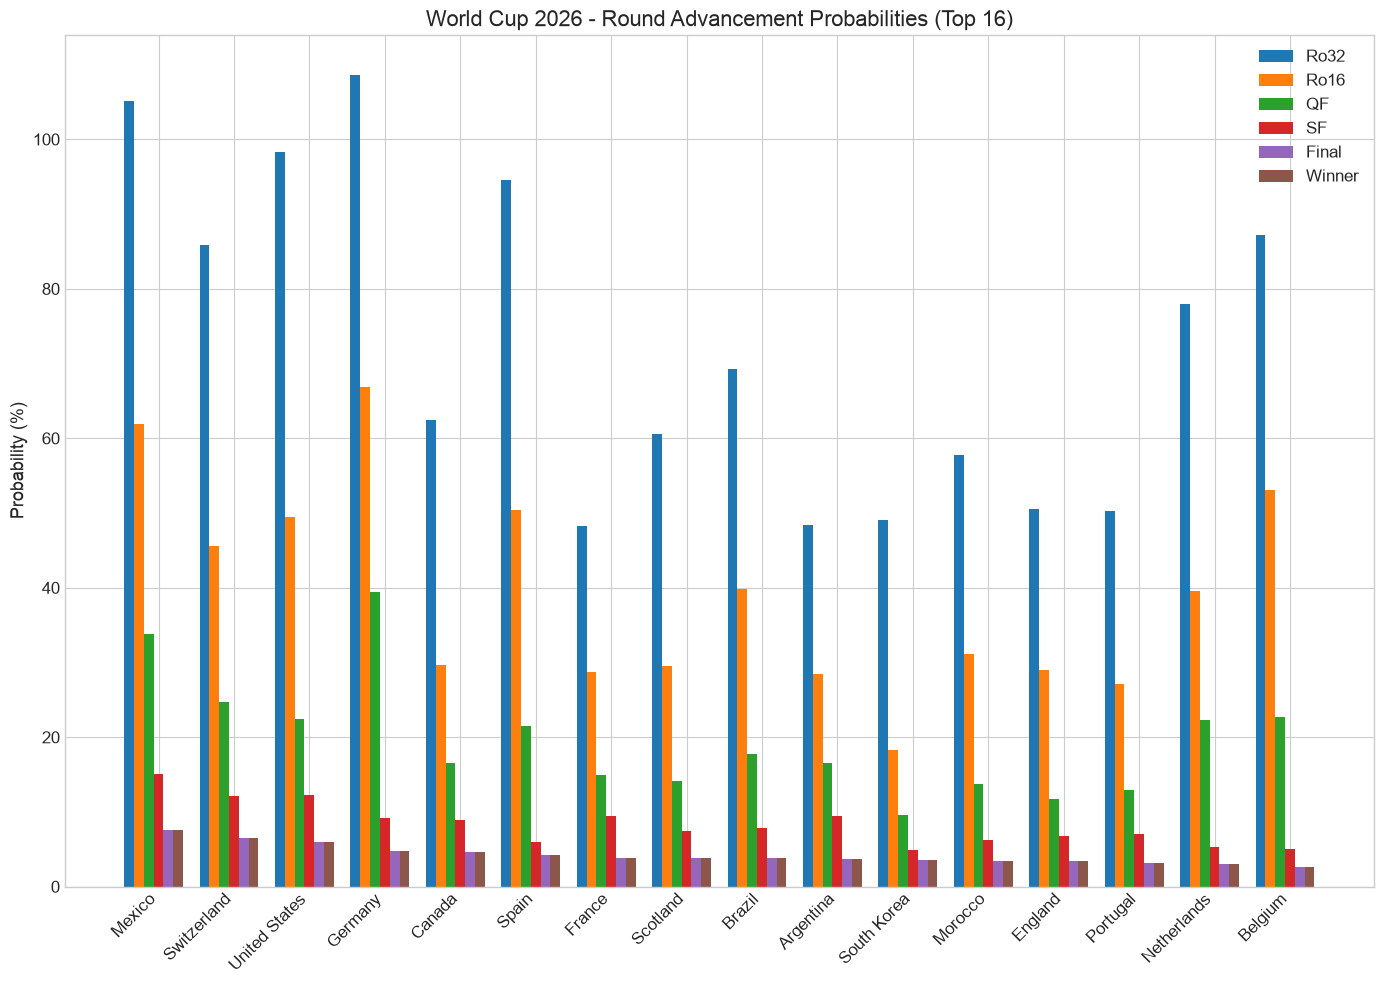

In [7]:
plot_round_probabilities(results, save=False)
plt.show()

## 6. Group Stage Probabilities

In [8]:
group_probs_path = PROCESSED_DIR / 'group_stage_probabilities.csv'
if group_probs_path.exists():
    group_probs = pd.read_csv(group_probs_path)
    group_tables = format_group_tables(group_probs)
    print(group_tables)
else:
    print('Group probabilities not found. Run simulation first.')

2026-06-15 09:14:40,644 [INFO] worldcup: Formatting group tables...
2026-06-15 09:14:40,648 [INFO] worldcup: 
                    WORLD CUP 2026 GROUP STAGE PROBABILITIES                    

Group A:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Mexico                   81.20     17.00     1.70      0.10      99.90     
South Korea              15.30     60.90     20.40     3.40      96.10     
Czech Republic           2.60      15.70     48.00     33.70     56.30     
South Africa             0.90      6.40      29.90     62.80     31.00     

Group B:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Switzerla

                    WORLD CUP 2026 GROUP STAGE PROBABILITIES                    

Group A:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Mexico                   81.20     17.00     1.70      0.10      99.90     
South Korea              15.30     60.90     20.40     3.40      96.10     
Czech Republic           2.60      15.70     48.00     33.70     56.30     
South Africa             0.90      6.40      29.90     62.80     31.00     

Group B:
--------------------------------------------------------------------------------
Team                     1st%      2nd%      3rd%      4th%      Advance%  
--------------------------------------------------------------------------------
Switzerland              59.90     25.60     12.40     2.10      97.20     
Canada                   30.10     47.80   

2026-06-15 09:14:40,651 [INFO] worldcup: Plotting group stage heatmaps...


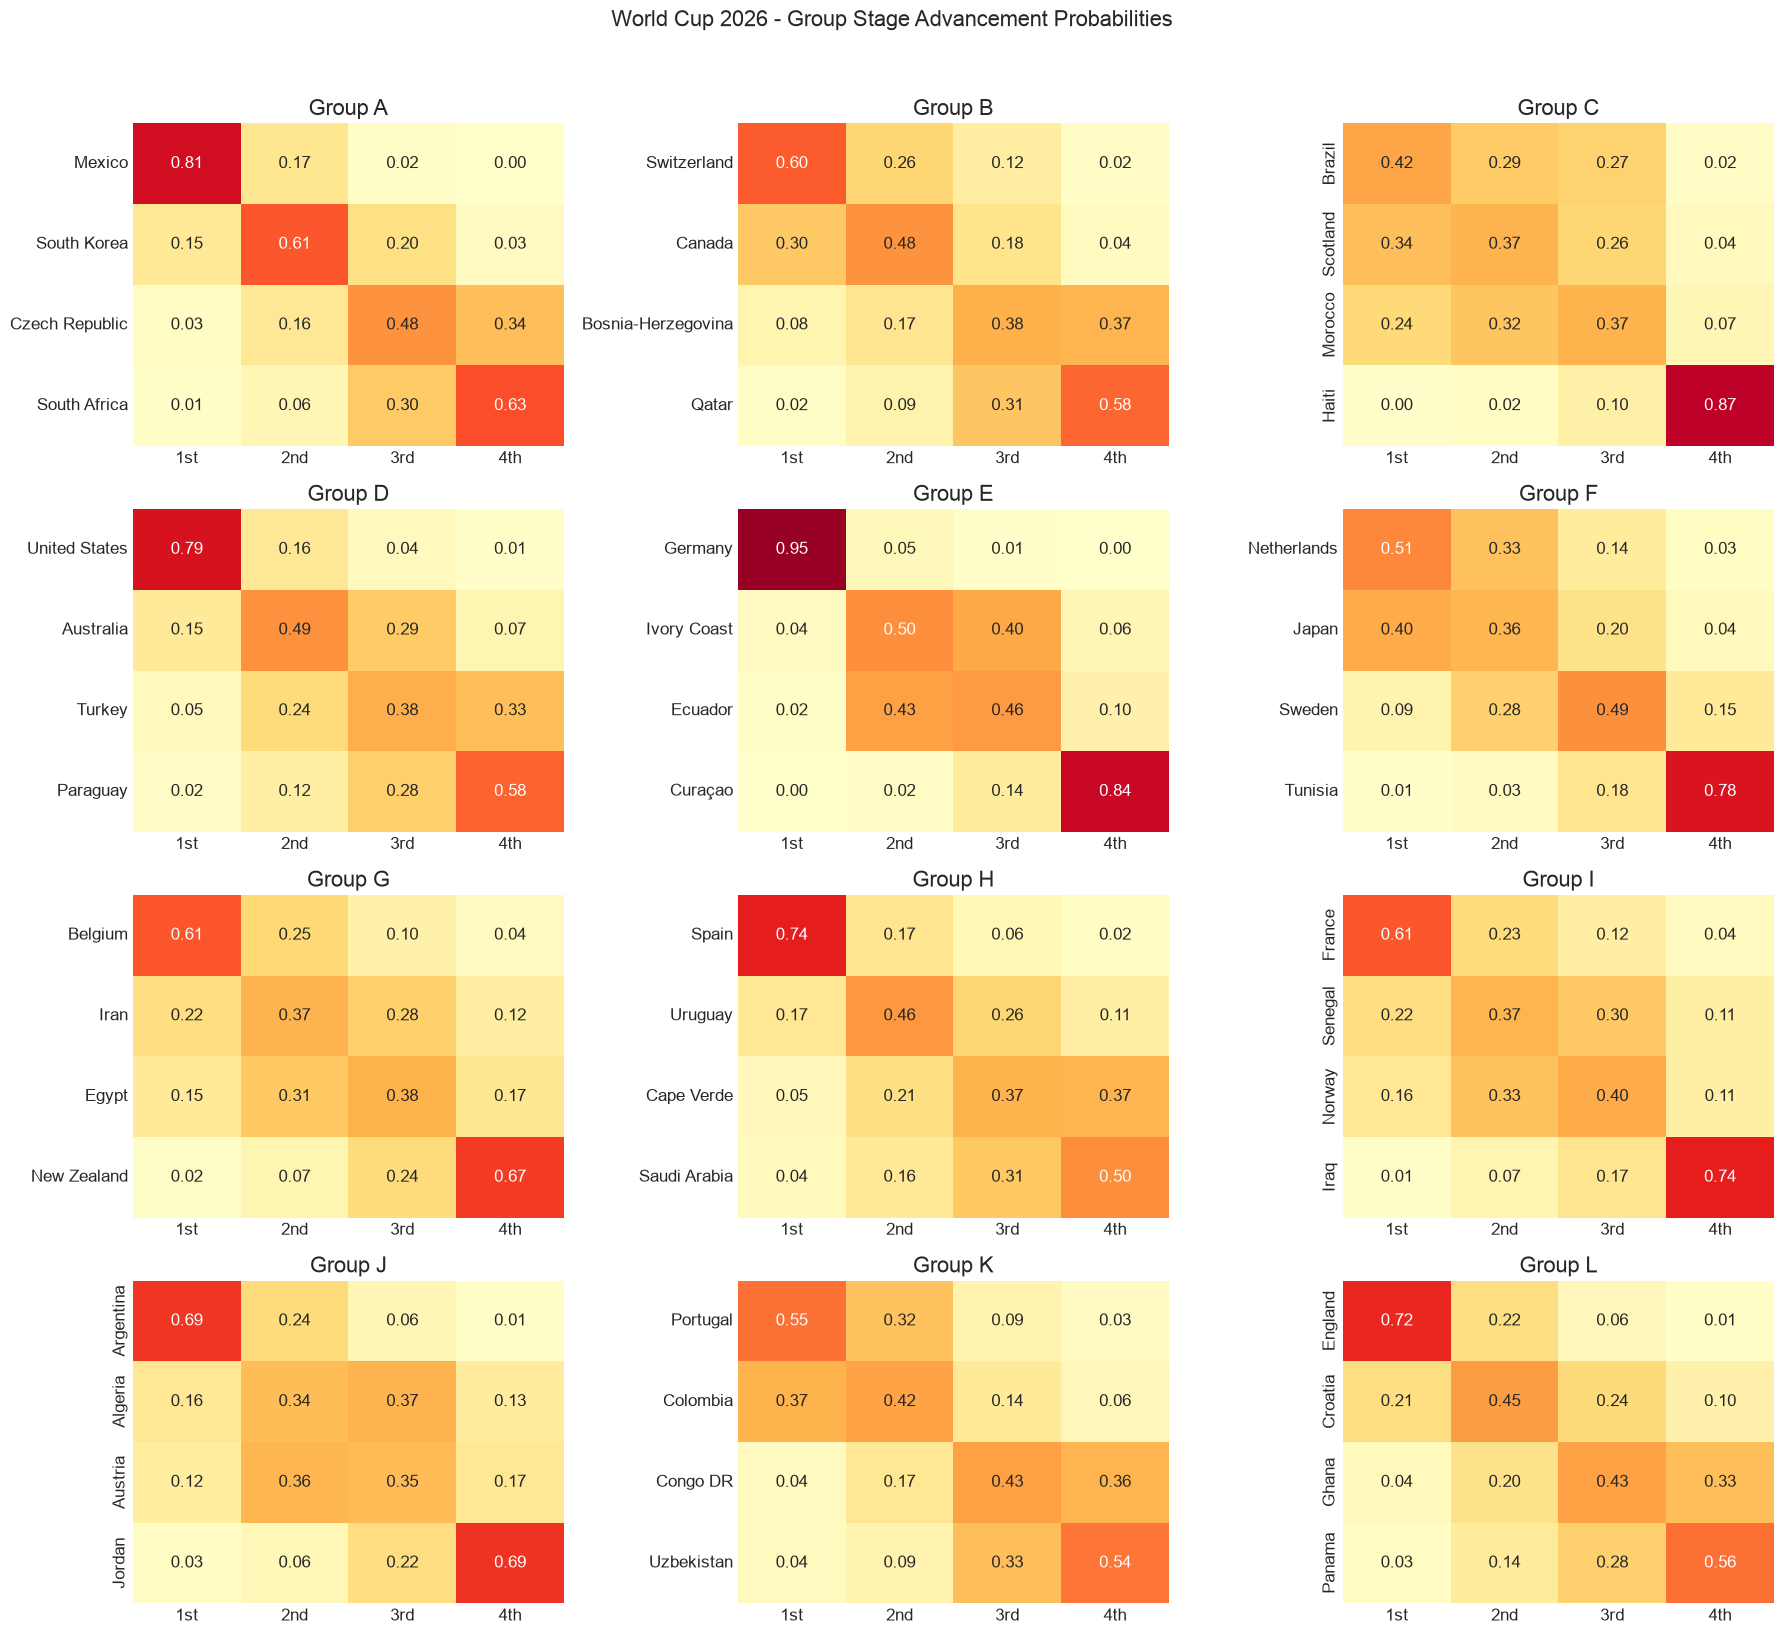

In [9]:
if group_probs_path.exists():
    plot_group_heatmaps(group_probs, save=False)
    plt.show()

## 7. Bracket Summary

In [10]:
bracket_summary = format_bracket_summary(results)
print(bracket_summary)

2026-06-15 09:14:42,272 [INFO] worldcup: Formatting bracket summary...
2026-06-15 09:14:42,273 [INFO] worldcup: 
                    WORLD CUP 2026 BRACKET SUMMARY                    
Team                     Winner    Final     SF        QF        R16       
----------------------------------------------------------------------
Mexico                   7.60      7.60      15.10     33.80     61.90     
Switzerland              6.50      6.50      12.10     24.70     45.60     
United States            6.00      6.00      12.30     22.50     49.40     
Germany                  4.80      4.80      9.20      39.40     66.90     
Canada                   4.70      4.70      8.90      16.50     29.70     
Spain                    4.30      4.30      6.00      21.50     50.40     
France                   3.90      3.90      9.40      15.00     28.70     
Scotland                 3.90      3.90      7.50      14.20     29.50     
Brazil                   3.90      3.90      7.90      17.70 

                    WORLD CUP 2026 BRACKET SUMMARY                    
Team                     Winner    Final     SF        QF        R16       
----------------------------------------------------------------------
Mexico                   7.60      7.60      15.10     33.80     61.90     
Switzerland              6.50      6.50      12.10     24.70     45.60     
United States            6.00      6.00      12.30     22.50     49.40     
Germany                  4.80      4.80      9.20      39.40     66.90     
Canada                   4.70      4.70      8.90      16.50     29.70     
Spain                    4.30      4.30      6.00      21.50     50.40     
France                   3.90      3.90      9.40      15.00     28.70     
Scotland                 3.90      3.90      7.50      14.20     29.50     
Brazil                   3.90      3.90      7.90      17.70     39.80     
Argentina                3.70      3.70      9.50      16.50     28.50     
South Korea           

## 8. What-If Scenarios

In [11]:
top_teams = results.head(10)['team'].tolist()
print('Top 10 teams by winning probability:')
for i, team in enumerate(top_teams, 1):
    prob = results[results['team'] == team]['prob_winner'].values[0]
    print(f'  {i}. {team}: {prob:.4f}')

Top 10 teams by winning probability:
  1. Mexico: 0.0760
  2. Switzerland: 0.0650
  3. United States: 0.0600
  4. Germany: 0.0480
  5. Canada: 0.0470
  6. Spain: 0.0430
  7. France: 0.0390
  8. Scotland: 0.0390
  9. Brazil: 0.0390
  10. Argentina: 0.0370


## 9. Key Insights & Analysis

In [12]:
from src.visualization.insights import (
    compute_confederation_stats,
    compute_host_nation_impact,
    compute_draw_analysis,
    compute_dark_horses,
    compute_surprise_matches,
    compute_most_competitive_groups,
    compare_with_odds,
)

group_probs = pd.read_csv(PROCESSED_DIR / 'group_stage_probabilities.csv')

### 9a. Model Performance Summary

In [13]:
eval_path = PROCESSED_DIR / 'evaluation' / 'model_comparison.csv'
if eval_path.exists():
    eval_df = pd.read_csv(eval_path)
    print('Model Performance on Test Set:')
    print(eval_df.to_string(index=False))
    best = eval_df.iloc[0]
    print(f'\nBest model: {best["Model"]} — Accuracy: {best["Accuracy"]:.4f}, Log Loss: {best["Log Loss"]:.4f}')
else:
    print('Model evaluation not found. Run training pipeline first.')

Model Performance on Test Set:
             Model  Accuracy  Log Loss  Brier (home_win)  Brier (draw)  Brier (away_win)  Avg Brier
      BestEnsemble  0.619523  0.837303          0.173257      0.169677          0.147112   0.163349
      Randomforest  0.600111  0.859092          0.181281      0.173711          0.150429   0.168474
Logisticregression  0.568220  0.877595          0.189900      0.178812          0.149210   0.172641
           Xgboost  0.563228  0.888022          0.179528      0.191958          0.156254   0.175913
         Neuralnet  0.608430  1.454364          0.233795      0.201457          0.183748   0.206333

Best model: BestEnsemble — Accuracy: 0.6195, Log Loss: 0.8373


### 9b. Confederation Analysis

In [14]:
confed_stats = compute_confederation_stats(results)
print('Confederation Strength Overview:')
print(confed_stats.to_string(index=False))
print(f'\nKey takeaway: {confed_stats.iloc[0]["confederation"]} teams average the highest win probability ({confed_stats.iloc[0]["avg_prob_winner"]:.1f}%),')
print(f'led by {confed_stats.iloc[0]["best_team"]} ({confed_stats.iloc[0]["best_team_win_pct"]:.1f}%).')

Confederation Strength Overview:
confederation  n_teams  avg_prob_winner  avg_prob_advance_ro16  avg_prob_qf   best_team  best_team_win_pct
     CONCACAF        6         3.100000              24.883333    12.783333      Mexico                7.6
         UEFA       16         2.912500              29.812500    14.956250 Switzerland                6.5
     CONMEBOL        6         2.133333              21.283333    10.316667      Brazil                3.9
          CAF       10         1.290000              12.900000     6.580000     Morocco                3.4
          AFC        9         1.011111              12.633333     6.100000 South Korea                3.6
          OFC        1         0.000000               3.300000     1.400000 New Zealand                0.0

Key takeaway: CONCACAF teams average the highest win probability (3.1%),
led by Mexico (7.6%).


### 9c. Host Nation Advantage

In [15]:
host_impact = compute_host_nation_impact(results, match_preds)
print('Host Nation Performance:')
for host, data in host_impact.items():
    print(f'  {host}:')
    print(f'    Win: {data["prob_winner"]:.1f}% | Final: {data["prob_final"]:.1f}% | SF: {data["prob_sf"]:.1f}% | QF: {data["prob_qf"]:.1f}% | Ro16: {data["prob_ro16"]:.1f}%')
    print(f'    Home matches: predicted {data["home_matches_predicted_wins"]}/{data["home_matches_total"]} wins (avg home win prob: {data["avg_home_win_pct"]:.1f}%)')

total_host_win = sum(d['prob_winner'] for d in host_impact.values())
print(f'\nCombined host win probability: {total_host_win:.1f}% (hosts hold {total_host_win:.1f}% of total win probability across 48 teams)')

Host Nation Performance:
  United States:
    Win: 6.0% | Final: 6.0% | SF: 12.3% | QF: 22.5% | Ro16: 49.4%
    Home matches: predicted 2/3 wins (avg home win prob: 46.7%)
  Canada:
    Win: 4.7% | Final: 4.7% | SF: 8.9% | QF: 16.5% | Ro16: 29.7%
    Home matches: predicted 2/2 wins (avg home win prob: 64.0%)
  Mexico:
    Win: 7.6% | Final: 7.6% | SF: 15.1% | QF: 33.8% | Ro16: 61.9%
    Home matches: predicted 2/3 wins (avg home win prob: 54.6%)

Combined host win probability: 18.3% (hosts hold 18.3% of total win probability across 48 teams)


### 9d. Draw Prediction Analysis

In [16]:
draw_info = compute_draw_analysis(match_preds)
print(f'Draw Prediction Summary:')
print(f'  Predicted draws: {draw_info["predicted_draws"]}/{draw_info["total_matches"]} ({draw_info["draw_rate"]:.1f}%)')
print(f'  Predicted home wins: {draw_info["predicted_home_wins"]} ({draw_info["predicted_home_wins"]/draw_info["total_matches"]*100:.1f}%)')
print(f'  Predicted away wins: {draw_info["predicted_away_wins"]} ({draw_info["predicted_away_wins"]/draw_info["total_matches"]*100:.1f}%)')
print(f'  Average draw probability: {draw_info["avg_draw_prob"]:.1f}%')
print(f'  Range: {draw_info["min_draw_prob"]:.1f}% — {draw_info["max_draw_prob"]:.1f}%')
print(f'\nTop 10 most likely draws:')
print(draw_info['high_draw_matches'].to_string(index=False))

Draw Prediction Summary:
  Predicted draws: 24/72 (33.3%)
  Predicted home wins: 41 (56.9%)
  Predicted away wins: 7 (9.7%)
  Average draw probability: 37.6%
  Range: 25.0% — 69.6%

Top 10 most likely draws:
group     home_team      away_team  prob_draw
    G       Belgium          Egypt     0.6962
    I       Senegal         Norway     0.6954
    K      Congo DR     Uzbekistan     0.6401
    C      Scotland        Morocco     0.6005
    D United States       Paraguay     0.5728
    A        Mexico Czech Republic     0.5696
    I          Iraq         Norway     0.5571
    D     Australia       Paraguay     0.5525
    G         Egypt    New Zealand     0.5389
    L         Ghana         Panama     0.5348


### 9e. Dark Horses & Underdogs

In [17]:
dark_horses = compute_dark_horses(results, group_probs)
if not dark_horses.empty:
    print('Top 10 Non-UEFA/CONMEBOL Teams (Dark Horses):')
    cols = ['team', 'prob_winner', 'prob_advance', 'prob_1st_in_group']
    display_cols = {c: c.replace('_', ' ').title() for c in cols}
    print(dark_horses[cols].rename(columns=display_cols).to_string(index=False))
    print(f'\nKey insight: Mexico leads all dark horses at {dark_horses.iloc[0]["prob_winner"]*100:.1f}%,')
    print(f'benefiting from host advantage and a {dark_horses.iloc[0]["prob_advance"]:.0f}% group advancement probability.')

Top 10 Non-UEFA/CONMEBOL Teams (Dark Horses):
         Team  Prob Winner  Prob Advance  Prob 1St In Group
       Mexico        0.076          99.9               81.2
United States        0.060          99.0               78.6
       Canada        0.047          94.1               30.1
  South Korea        0.036          96.1               15.3
      Morocco        0.034          90.9               24.4
      Senegal        0.024          79.1               22.0
  Ivory Coast        0.023          82.5                3.5
        Japan        0.018          93.3               39.7
        Egypt        0.015          67.2               14.8
      Algeria        0.015          74.4               16.2

Key insight: Mexico leads all dark horses at 7.6%,
benefiting from host advantage and a 100% group advancement probability.


### 9f. Most Competitive Groups

In [18]:
comp_groups = compute_most_competitive_groups(group_probs)
print('Group Competitiveness (sorted by tightness):')
print(comp_groups.to_string(index=False))
tight = comp_groups[comp_groups['is_tight']]
if not tight.empty:
    print(f'\nTightest group: Group {tight.iloc[0]["group"]} (advance spread: {tight.iloc[0]["advance_spread"]:.1f}%)')
    print(f'  Most likely 1st: {tight.iloc[0]["most_likely_1st"]} ({tight.iloc[0]["most_likely_1st_pct"]:.1f}%)')
else:
    least_spread = comp_groups.iloc[0]
    print(f'\nTightest group: Group {least_spread["group"]} (advance spread: {least_spread["advance_spread"]:.1f}%)')

Group Competitiveness (sorted by tightness):
group  advance_spread  avg_advance_pct most_likely_1st  most_likely_1st_pct  is_tight
    B            60.3           71.825     Switzerland                 59.9     False
    D            62.2           72.075   United States                 78.6     False
    H            63.7           61.700           Spain                 74.2     False
    K            68.6           61.475        Portugal                 55.3     False
    A            68.9           70.825          Mexico                 81.2     False
    L            69.9           61.025         England                 71.6     False
    G            76.1           64.000         Belgium                 61.2     False
    I            77.0           64.825          France                 60.7     False
    J            79.8           65.000       Argentina                 68.6     False
    F            83.2           67.300     Netherlands                 51.0     False
    C    

### 9g. Surprise Predictions & Upset Alerts

In [19]:
surprises = compute_surprise_matches(match_preds)
if not surprises.empty:
    print('Top 10 Most Surprising Predictions (away wins & draws that defy home advantage):')
    print(surprises.to_string(index=False))
    top = surprises.iloc[0]
    print(f'\nBiggest upset alert: {top["home_team"]} vs {top["away_team"]} — model predicts {top["prediction"]}')
    print(f'  Away win prob: {top["prob_away_win"]*100:.1f}%, Home win prob: {top["prob_home_win"]*100:.1f}%')

Top 10 Most Surprising Predictions (away wins & draws that defy home advantage):
group     home_team  away_team  prob_home_win  prob_draw  prob_away_win prediction  surprise_score
    I       Senegal     Norway         0.1390     0.6954         0.1656       draw          0.5298
    G       Belgium      Egypt         0.1719     0.6962         0.1319       draw          0.5243
    K      Congo DR   Colombia         0.1010     0.2865         0.6125   away_win          0.5115
    K    Uzbekistan   Colombia         0.0685     0.3811         0.5504   away_win          0.4819
    D     Australia     Turkey         0.1570     0.2500         0.5930   away_win          0.4360
    K      Congo DR Uzbekistan         0.2662     0.6401         0.0937       draw          0.3739
    C      Scotland    Morocco         0.1693     0.6005         0.2302       draw          0.3703
    C      Scotland     Brazil         0.1289     0.4181         0.4530   away_win          0.3241
    D     Australia   Paragu

### 9h. Model vs Betting Odds Comparison

In [20]:
odds_comparison = compare_with_odds(results)
if odds_comparison is not None:
    print('Model vs Betting Odds (FIFA ranking fallback):')
    print(odds_comparison.to_string(index=False))
    over = odds_comparison[odds_comparison['diff_pct'] > 0]
    under = odds_comparison[odds_comparison['diff_pct'] < 0]
    if not over.empty:
        print(f'\nModel overvalues vs odds: {", ".join(over["team"].tolist())}')
    if not under.empty:
        print(f'Model undervalues vs odds: {", ".join(under["team"].tolist())}')
else:
    print('Betting odds data not available. Set ODDS_API_KEY and re-run data pipeline.')

Model vs Betting Odds (FIFA ranking fallback):
         team  model_prob  odds_prob  diff_pct
       Mexico       0.076   0.036289  3.971082
  Switzerland       0.065   0.030097  3.490318
United States       0.060   0.033457  2.654272
      Germany       0.048   0.046200  0.180047
        Spain       0.043   0.092543 -4.954264
       France       0.039   0.090706 -5.170564
       Brazil       0.039   0.053700 -1.470035
    Argentina       0.037   0.093735 -5.673480
      Morocco       0.034   0.050888 -1.688761
      England       0.034   0.073275 -3.927500
     Portugal       0.032   0.054237 -2.223734
  Netherlands       0.030   0.050500 -2.049981
      Belgium       0.026   0.047719 -2.171852
      Senegal       0.024   0.035676 -1.167569
        Japan       0.018   0.031881 -1.388130
      Croatia       0.016   0.041615 -2.561537
     Colombia       0.016   0.038316 -2.231608
      Uruguay       0.011   0.033767 -2.276651
         Iran       0.007   0.025842 -1.884248

Model overva

### 9i. Simulation Summary

In [21]:
print('=' * 80)
print(f'{"WORLD CUP 2026 PREDICTION SUMMARY":^80}')
print('=' * 80)
print(f'Simulations run: {n_sim:,}')
print(f'Model: XGBoost (fast simulation mode)')
print(f'Matches predicted: {len(match_preds)} group stage')
print(f'')
print(f'Winner probabilities: Top 5')
for i, row in results.head(5).iterrows():
    print(f'  {i+1}. {row["team"]}: {row["prob_winner"]*100:.1f}%')
print(f'')
print(f'Host nations (combined): {sum(host_impact[h]["prob_winner"] for h in host_impact):.1f}% win probability')
print(f'Predicted draw rate: {draw_info["draw_rate"]:.1f}% ({draw_info["predicted_draws"]}/{draw_info["total_matches"]} matches)')
print(f'Most competitive group: Group {comp_groups.iloc[0]["group"]} (spread: {comp_groups.iloc[0]["advance_spread"]:.1f}%)')
if not surprises.empty:
    top_s = surprises.iloc[0]
    print(f'Biggest upset alert: {top_s["away_team"]} over {top_s["home_team"]} ({top_s["prob_away_win"]*100:.1f}%)')
print('=' * 80)

                       WORLD CUP 2026 PREDICTION SUMMARY                        
Simulations run: 1,000
Model: XGBoost (fast simulation mode)
Matches predicted: 72 group stage

Winner probabilities: Top 5
  1. Mexico: 7.6%
  2. Switzerland: 6.5%
  3. United States: 6.0%
  4. Germany: 4.8%
  5. Canada: 4.7%

Host nations (combined): 18.3% win probability
Predicted draw rate: 33.3% (24/72 matches)
Most competitive group: Group B (spread: 60.3%)
Biggest upset alert: Norway over Senegal (16.6%)
